# Week 2 - Day 1 Solution
## Data Splitting and Missing Values (Ames Housing)

https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset

Today we introduce a richer, messier dataset and establish the two preprocessing habits that carry through the rest of the course:
- **Three-way split** (train / validation / test) with strict roles for each set
- **Domain-aware imputation** — treating nulls that mean 'not present' differently from nulls that mean 'unknown'

**Output of today's session:** three null-free matrices (`X_train_imp`, `X_val_imp`, `X_test_imp`) ready for encoding and scaling in Day 2.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

## 1) Load Ames Housing Dataset

Ames Housing contains 1,460 residential property sales in Ames, Iowa with 80 features covering size, quality, age, neighborhood, garage, basement, and more.  
Target: `SalePrice` (continuous regression).

In [ ]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()

# Convert target to numeric (OpenML sometimes loads it as string)
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

print(f'Shape: {df.shape}')
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# How many numeric vs categorical columns?
print('Column type breakdown:')
print(df.dtypes.value_counts())
print(f'\nNumeric columns : {df.select_dtypes(include="number").shape[1]}')
print(f'Categorical cols: {df.select_dtypes(include="object").shape[1]}')

Column type breakdown:
object     43
int64      35
float64     3
Name: count, dtype: int64

Numeric columns : 38
Categorical cols: 43


In [ ]:
# Summary statistics for numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


In [ ]:
# How many unique values in each categorical column?
cat_cols = df.select_dtypes(include='object').columns
cat_cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print('Categorical column cardinality (unique values):')
print(cat_cardinality.to_string())

Categorical column cardinality (unique values):
Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
BsmtExposure      4
MiscFeature       4
KitchenQual       4
Fence             4
MasVnrType        4
BsmtCond          4
BsmtQual          4
ExterQual         4
PoolQC            3
GarageFinish      3
PavedDrive        3
LandSlope         3
Utilities         2
Alley             2
Street            2
CentralAir        2


In [ ]:
# Sample values from a few key categorical columns to understand the encoding
sample_cols = ['OverallQual', 'BsmtQual', 'KitchenQual', 'GarageType', 'Neighborhood']
for col in sample_cols:
    if col in df.columns:
        print(f'{col}: {df[col].value_counts().head(5).to_dict()}')

OverallQual: {5: 397, 6: 374, 7: 319, 8: 168, 4: 116}
BsmtQual: {'TA': 649, 'Gd': 618, 'Ex': 121, 'Fa': 35}
KitchenQual: {'TA': 735, 'Gd': 586, 'Ex': 100, 'Fa': 39}
GarageType: {'Attchd': 870, 'Detchd': 387, 'BuiltIn': 88, 'Basment': 19, 'CarPort': 9}
Neighborhood: {'NAmes': 225, 'CollgCr': 150, 'OldTown': 113, 'Edwards': 100, 'Somerst': 86}


### Instructor Notes — Load Ames Housing Dataset

**Code:** We load the Ames Housing dataset via `fetch_openml(name='house_prices')`, copy it into a DataFrame, and convert `SalePrice` to numeric. We then run four quick audits: shape, dtype breakdown, summary statistics, categorical cardinality, and sample value counts for key columns.

**Output:**
- **Shape:** 1,460 rows x 81 columns (80 features + 1 target). This is 3x wider than California Housing (8 features) — the jump from Week 1's clean dataset to a real-world, messy one is intentional.
- **Dtype breakdown:** 43 categorical (`object`) columns, 35 integer, 3 float — a roughly even mix. Most ML workflows in Week 1 used only numeric data; this week, students must handle categoricals.
- **Categorical cardinality:** ranges from 2 (`Street`, `CentralAir` — binary) to 25 (`Neighborhood`). High-cardinality columns like `Neighborhood` will matter for encoding decisions in Day 2 — one-hot encoding creates 25 columns for `Neighborhood` alone.
- **Sample value counts:** `OverallQual` peaks at 5 and 6 (typical-quality houses), `BsmtQual` and `KitchenQual` are dominated by `TA` (typical/average), `GarageType` is overwhelmingly `Attchd` (attached). These distributions will inform imputation strategy later — the mode for `BsmtQual` is `TA`, which is the correct fill for low-null recording gaps.

**Why Ames Housing instead of California Housing again:** California Housing is clean — no missing values, no categoricals, only 8 features. Ames Housing is the opposite: 19 columns have nulls, 43 columns are categorical, and the missing data has domain meaning (no pool, no garage, no basement). This forces students to handle real preprocessing problems rather than skip them.

**The `fetch_openml` + `.copy()` pattern:** `fetch_openml` returns a Bunch object; `.frame` extracts the combined DataFrame. We immediately call `.copy()` to detach our working DataFrame from the sklearn object — this avoids subtle SettingWithCopyWarning issues if we later modify columns in place.

**Why convert SalePrice explicitly:** OpenML sometimes loads numeric targets as strings. `pd.to_numeric(errors='coerce')` is defensive — if any value is non-numeric, it becomes `NaN` rather than crashing. This is a good habit for any data-loading step.

**Discussion prompt:** "We have 43 categorical columns and 38 numeric columns. Can we feed all 81 columns directly into `LinearRegression()`?" → No. `LinearRegression` (and most sklearn estimators) requires a numeric matrix. Categorical columns must be encoded first — typically one-hot encoding for low-cardinality features and target/ordinal encoding for high-cardinality ones. That is the focus of Day 2.

## 2) Target Variable Analysis

Before splitting, understand the shape of what we are predicting.  
A right-skewed target can affect model performance and metric interpretation.

SalePrice summary:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

Skewness: 1.883
Kurtosis: 6.536


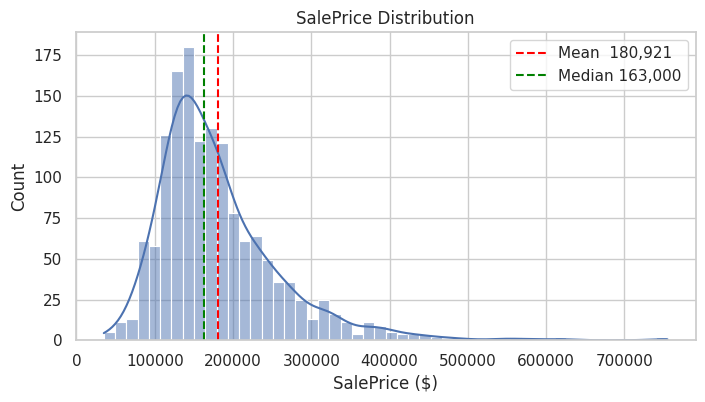

In [ ]:
print('SalePrice summary:')
print(df['SalePrice'].describe().round(0))
print(f'\nSkewness: {df["SalePrice"].skew():.3f}')
print(f'Kurtosis: {df["SalePrice"].kurt():.3f}')

plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.axvline(df['SalePrice'].mean(),   color='red',   linestyle='--', label=f'Mean  {df["SalePrice"].mean():,.0f}')
plt.axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median {df["SalePrice"].median():,.0f}')
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice ($)')
plt.legend()
plt.show()

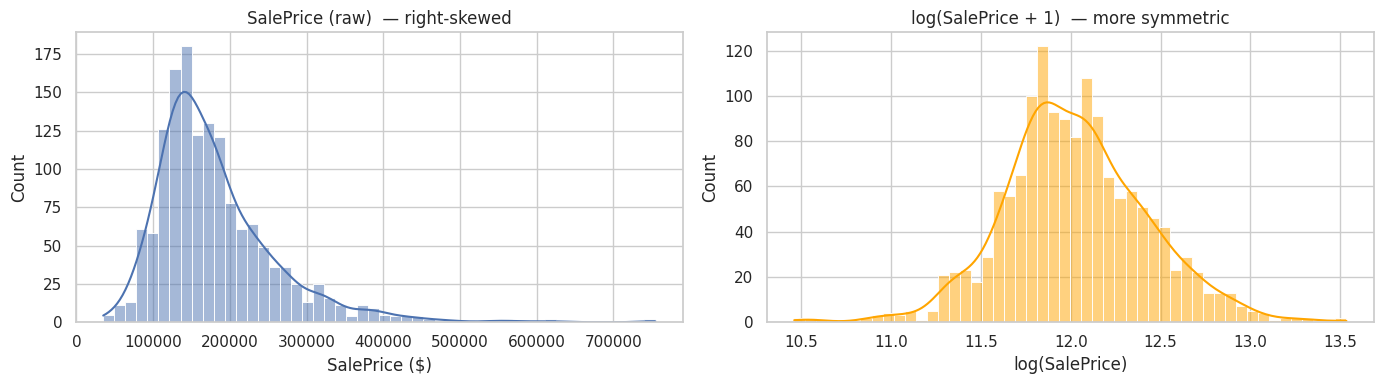

Note: We will model raw SalePrice today. Log-transformation is a Day 4 refinement.


In [ ]:
# Log-transform comparison: raw vs log(SalePrice)
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('SalePrice (raw)  — right-skewed')
axes[0].set_xlabel('SalePrice ($)')

sns.histplot(np.log1p(df['SalePrice']), bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('log(SalePrice + 1)  — more symmetric')
axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()
plt.show()

print('Note: We will model raw SalePrice today. Log-transformation is a Day 4 refinement.')

In [ ]:
# SalePrice quartile breakdown
quartiles = pd.qcut(df['SalePrice'], q=4, labels=['Q1 (cheap)', 'Q2', 'Q3', 'Q4 (expensive)'])
print('SalePrice quartile ranges:')
print(df.groupby(quartiles, observed=True)['SalePrice'].agg(['min', 'max', 'count']))

SalePrice quartile ranges:
                   min     max  count
SalePrice                            
Q1 (cheap)       34900  129900    365
Q2              130000  163000    367
Q3              163500  214000    366
Q4 (expensive)  214500  755000    362


### Instructor Notes — Target Variable Analysis

**Code:** We compute summary statistics, skewness, and kurtosis for `SalePrice`, then visualise the raw distribution with mean/median lines, compare raw vs log-transformed distributions side by side, and break `SalePrice` into quartiles.

**Output:**
- **SalePrice summary:** mean = $180,921, median = $163,000, std = $79,443, min = $34,900, max = $755,000
- **Skewness = 1.883:** strongly right-skewed — a long right tail of expensive houses pulls the mean above the median by ~$18k
- **Kurtosis = 6.536:** heavy-tailed compared to a normal distribution (kurtosis = 3), indicating more extreme values than a Gaussian would predict
- **Log-transform:** `log(SalePrice + 1)` produces a nearly symmetric, bell-shaped distribution — much closer to normal
- **Quartile breakdown:** Q1 ($34.9k–$129.9k, 365 houses), Q2 ($130k–$163k, 367), Q3 ($163.5k–$214k, 366), Q4 ($214.5k–$755k, 362) — roughly equal counts confirm `qcut` is working correctly

**Why skewness matters for regression:** Linear regression assumes that errors are roughly normally distributed and that the target has constant variance. A right-skewed target violates both: errors are larger for expensive houses, and the mean is pulled toward outliers. Log-transforming the target compresses the right tail and stabilises variance — models trained on `log(SalePrice)` often achieve lower RMSE after back-transforming predictions.

**Why we don't log-transform today:** The notebook notes this explicitly: "We will model raw SalePrice today. Log-transformation is a Day 4 refinement." This is a deliberate pedagogical choice. Today's focus is splitting and imputation. Introducing a target transform adds complexity (predictions must be exponentiated back) that would distract from the core lesson. Students should know the technique exists, but we defer it.

**The mean vs median gap as a diagnostic:** When mean ($180,921) exceeds median ($163,000) by more than 10%, the distribution is meaningfully skewed. The red (mean) and green (median) vertical lines on the histogram make this gap visible. For a symmetric distribution, the two lines would overlap.

**Discussion prompt:** "If we trained a linear model on raw SalePrice vs log(SalePrice), which would give a lower percentage error on expensive houses?" → Log(SalePrice). The log transform shrinks the scale of expensive houses, so the model optimises for percentage error rather than dollar error. On raw SalePrice, a $50k error on a $500k house (10%) and a $50k error on a $100k house (50%) are treated equally. On log scale, the $100k house error is penalised more heavily.

## 3) Three-Way Train / Validation / Test Split

We use a **60 / 20 / 20** split.

| Split | Size | Role | Rule |
|---|---|---|---|
| Train | ~60% | Model and preprocessor learning | `.fit()` only here |
| Validation | ~20% | Model comparison, tuning | Look as many times as needed |
| Test | ~20% | Final honest evaluation | Touch exactly once |

> **Rule:** if you use the test set to make any modeling decision, it is no longer a trustworthy estimate of future performance.

In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 1: 60% train, 40% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

# Step 2: split the 40% holdout evenly -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

total = len(df)
print(f'Train:      {len(X_train):4d} rows  ({len(X_train)/total*100:.0f}%)')
print(f'Validation: {len(X_val):4d} rows  ({len(X_val)/total*100:.0f}%)')
print(f'Test:       {len(X_test):4d} rows  ({len(X_test)/total*100:.0f}%)')
print(f'Total:      {total:4d} rows')

Train:       876 rows  (60%)
Validation:  292 rows  (20%)
Test:        292 rows  (20%)
Total:      1460 rows


### Instructor Notes — Three-Way Train / Validation / Test Split

**Code:** We separate `X` (features) and `y` (target), then perform a two-step split: first 60/40, then the 40% is halved into 20% validation and 20% test. Both calls use `random_state=42` for reproducibility.

**Output:**
- `Train:       876 rows  (60%)`
- `Validation:  292 rows  (20%)`
- `Test:        292 rows  (20%)`
- `Total:      1460 rows`

**Why a two-step split instead of one call:** `train_test_split` only produces two subsets. To get three, we call it twice: once to carve off 40%, then again to split that 40% in half. An alternative is to use `np.split`, but two calls to `train_test_split` is the idiomatic sklearn pattern and makes the intention explicit.

**Why 60/20/20 and not 80/20 (train/test only)?** With a two-way split, every modelling decision (feature selection, hyperparameter tuning, imputation strategy) is evaluated against the same test set. After enough decisions, the test set is no longer a fair estimate of future performance — it has been implicitly optimised against. The validation set absorbs that wear: we can evaluate against it as many times as needed, and the test set remains untouched until the final evaluation.

**The strict roles:**
- **Train (60%):** All `.fit()` calls happen here — imputers, scalers, encoders, and models. This is the only data the model ever learns from.
- **Validation (20%):** Used for model comparison and hyperparameter tuning. You can look at val metrics repeatedly to decide between Ridge vs Lasso, or to choose a regularisation strength. The val set is "spent" after tuning.
- **Test (20%):** Touched exactly once, at the very end, to report the final metric. If the test metric is much worse than validation, you have overfit to the validation set.

**Why `random_state` matters:** Without it, every run produces different splits. Two runs that differ only in split randomness will produce different RMSE values — and you cannot tell whether a metric change came from a code change or a data shuffle. Setting `random_state=42` eliminates that ambiguity.

**Discussion prompt:** "If we used the test set to pick between two models and then reported the test score of the winner — is that score still trustworthy?" → No. The act of choosing the model with the better test score is itself a decision informed by the test set. The reported test metric is now optimistically biased. This is exactly why the validation set exists — to make those choices without contaminating the test estimate.

## 4) Split Quality Check

A good random split produces similar target distributions across all three sets.  
We verify this before doing any further work — if the splits are wildly different, the evaluation will be misleading.

In [ ]:
# Compare SalePrice statistics across splits
split_comparison = pd.DataFrame({
    'Train':      y_train.describe(),
    'Validation': y_val.describe(),
    'Test':       y_test.describe()
}).round(0)

print('SalePrice distribution per split:')
split_comparison

SalePrice distribution per split:


,Train,Validation,Test
count,876.0,292.0,292.0
mean,179922.0,192100.0,172740.0
std,75389.0,97209.0,70053.0
min,34900.0,35311.0,52000.0
25%,129000.0,134900.0,128838.0
50%,164945.0,170000.0,153950.0
75%,213625.0,221908.0,206600.0
max,625000.0,755000.0,485000.0


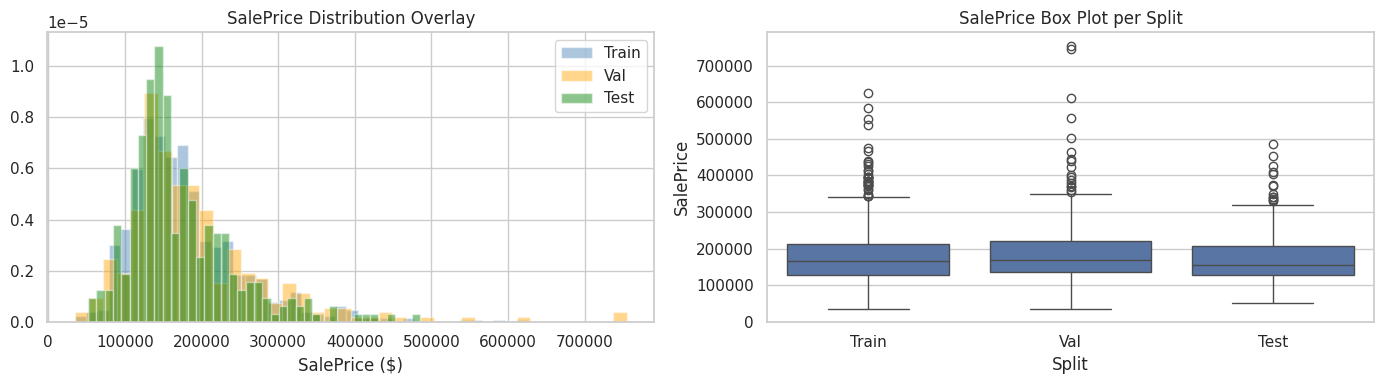

The three splits look similar — the random split is balanced.


In [ ]:
# Overlay SalePrice distributions across splits
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram overlay
for name, series, color in [('Train', y_train, 'steelblue'),
                              ('Val',   y_val,   'orange'),
                              ('Test',  y_test,  'green')]:
    axes[0].hist(series, bins=40, alpha=0.45, label=name, color=color, density=True)
axes[0].set_title('SalePrice Distribution Overlay')
axes[0].set_xlabel('SalePrice ($)')
axes[0].legend()

# Box plot
split_df = pd.DataFrame({
    'SalePrice': pd.concat([y_train, y_val, y_test]),
    'Split': (['Train'] * len(y_train) + ['Val'] * len(y_val) + ['Test'] * len(y_test))
})
sns.boxplot(data=split_df, x='Split', y='SalePrice', ax=axes[1],
            order=['Train', 'Val', 'Test'])
axes[1].set_title('SalePrice Box Plot per Split')

plt.tight_layout()
plt.show()

print('The three splits look similar — the random split is balanced.')

### Instructor Notes — Split Quality Check

**Code:** We compare `SalePrice` summary statistics (count, mean, std, min, quartiles, max) across the three splits, then overlay histograms and box plots to visually confirm distributional similarity.

**Output:**
- **Train:** mean = $179,922, median = $164,945, std = $75,389 (876 rows)
- **Validation:** mean = $192,100, median = $170,000, std = $97,209 (292 rows)
- **Test:** mean = $172,740, median = $153,950, std = $70,053 (292 rows)
- The histogram overlay shows all three distributions have the same right-skewed shape, peaking near $130k–$170k
- The box plots show similar interquartile ranges with a handful of high-value outliers in the validation set (up to $755k)

**Why the validation mean is higher:** The validation set happens to contain the single most expensive house ($755,000). With only 292 rows, one extreme value raises the mean by ~$12k compared to training. This is normal with small splits and does not indicate a bad split — the medians ($164,945 vs $170,000 vs $153,950) are much closer, which is the robust comparison.

**What a bad split looks like:** If the training set had a mean of $120k and the test set had a mean of $250k, the model would be trained on cheap houses and evaluated on expensive ones — the RMSE would be artificially inflated regardless of model quality. The consistency we see here (means within ~10% of each other) confirms the random split is sound.

**The role of `random_state=42`:** This makes the split deterministic. Every time the notebook runs, the same 876 rows land in training. This is critical for reproducibility — if a colleague re-runs the notebook and gets different results, the first thing to check is whether `random_state` was set.

**When random splitting is not enough:** For time-series data, random splitting violates temporal ordering (you would train on future data). For grouped data (e.g., multiple photos of the same patient), random splitting can leak patient identity across sets. In those cases, you need time-based or group-based splitting. For Ames Housing (cross-sectional, independent sales), random splitting is appropriate.

**Discussion prompt:** "The validation set std ($97,209) is much higher than train ($75,389). Is this a problem?" → Not necessarily. With 292 rows vs 876, the validation set is more sensitive to individual outliers. The $755k house inflates the std. If this concerns you, check whether removing that single row brings the validation std in line — it almost certainly does. The important thing is that the central tendency and shape are similar.

## 5) Missing Value Audit

Always audit missing values on the **training set only**. The validation and test sets are
future data — you must not look at their distributions to make preprocessing decisions.

For each null column we answer two questions:
1. How much is missing?
2. Does the null mean *not present* or *genuinely unknown*?

In [ ]:
# Null summary on training set only
null_counts = X_train.isnull().sum()
null_pct    = (null_counts / len(X_train) * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_pct,
    'dtype':      X_train.dtypes
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print(f'Columns with missing values: {len(null_summary)}')
null_summary

Columns with missing values: 19


,null_count,null_pct,dtype
PoolQC,872,99.5,object
MiscFeature,839,95.8,object
Alley,818,93.4,object
Fence,709,80.9,object
FireplaceQu,420,47.9,object
LotFrontage,167,19.1,float64
GarageCond,46,5.3,object
GarageType,46,5.3,object
GarageYrBlt,46,5.3,float64
GarageFinish,46,5.3,object


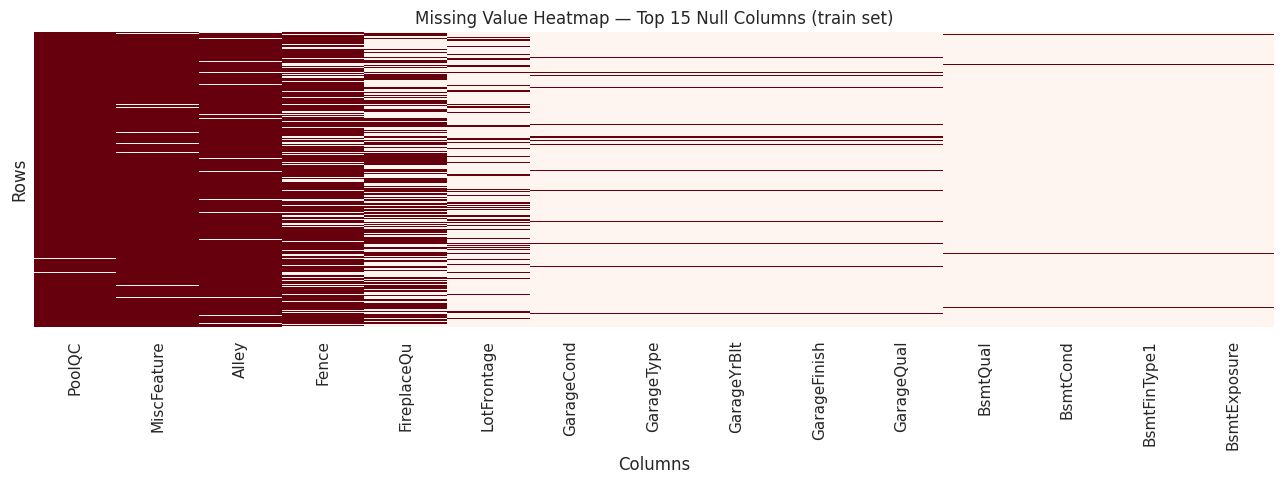

In [ ]:
# Missing value heatmap (top 15 null columns, train set)
top_null_cols = null_summary.head(15).index.tolist()

plt.figure(figsize=(13, 5))
sns.heatmap(X_train[top_null_cols].isnull(), cbar=False, yticklabels=False,
            cmap='Reds')
plt.title('Missing Value Heatmap — Top 15 Null Columns (train set)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

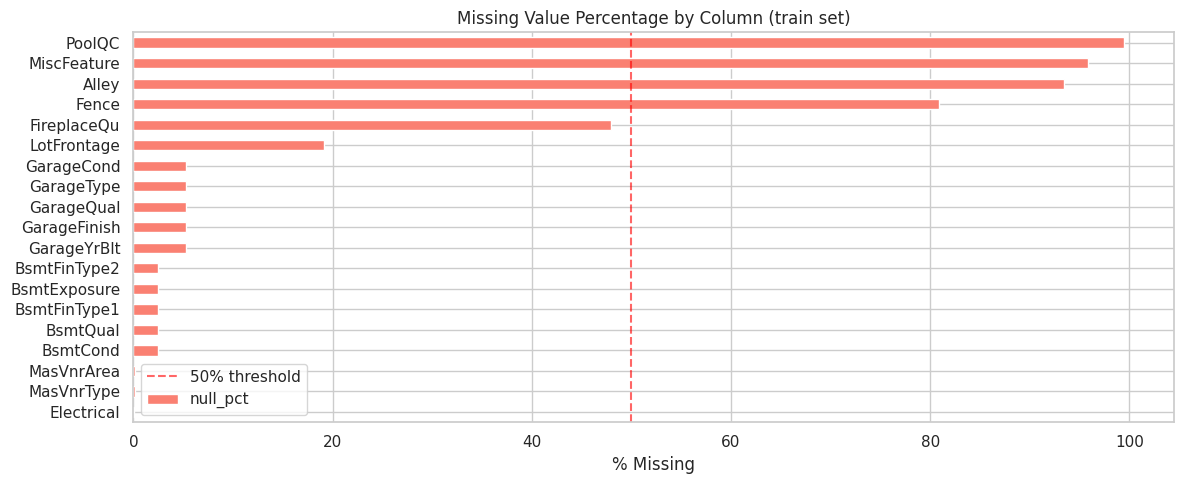

In [ ]:
# Bar chart of null percentages
plt.figure(figsize=(12, 5))
null_summary['null_pct'].sort_values(ascending=True).plot(
    kind='barh', color='salmon', edgecolor='white'
)
plt.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% threshold')
plt.title('Missing Value Percentage by Column (train set)')
plt.xlabel('% Missing')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Split null summary by dtype — helps plan strategy
print('Null columns by dtype:')
print(null_summary.groupby('dtype')['null_count'].count())
print()
print('Numeric nulls:')
print(null_summary[null_summary['dtype'] != 'object'][['null_count', 'null_pct']])
print()
print('Categorical nulls:')
print(null_summary[null_summary['dtype'] == 'object'][['null_count', 'null_pct']])

Null columns by dtype:
dtype
float64     3
object     16
Name: null_count, dtype: int64

Numeric nulls:
             null_count  null_pct
LotFrontage         167      19.1
GarageYrBlt          46       5.3
MasVnrArea            2       0.2

Categorical nulls:
              null_count  null_pct
PoolQC               872      99.5
MiscFeature          839      95.8
Alley                818      93.4
Fence                709      80.9
FireplaceQu          420      47.9
GarageCond            46       5.3
GarageType            46       5.3
GarageFinish          46       5.3
GarageQual            46       5.3
BsmtQual              22       2.5
BsmtCond              22       2.5
BsmtFinType1          22       2.5
BsmtExposure          22       2.5
BsmtFinType2          22       2.5
MasVnrType             2       0.2
Electrical             1       0.1


### Instructor Notes — Missing Value Audit

**Code:** We build a null summary DataFrame from `X_train` only — counting nulls, computing null percentages, and recording dtypes for every column. We then visualise the pattern three ways: a summary table sorted by null rate, a heatmap showing which rows are affected, and a horizontal bar chart of null percentages.

**Output:**
- 19 of 80 columns have at least one null in the training set
- `PoolQC` leads at 99.5% null (872 of 876 rows), followed by `MiscFeature` (95.8%), `Alley` (93.4%), `Fence` (80.9%)
- The garage cluster (`GarageCond`, `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`) all share exactly 46 nulls (5.3%) — a strong hint of co-occurrence
- Similarly, 5 basement columns each have exactly 22 nulls (2.5%)
- Only 3 numeric columns have nulls: `LotFrontage` (167, 19.1%), `GarageYrBlt` (46, 5.3%), `MasVnrArea` (2, 0.2%)
- The remaining 16 null columns are all categorical (dtype `object`)

**Why audit on training data only:** The validation and test sets represent future, unseen data. If we inspected their null distributions to choose an imputation strategy, we would bake future information into our preprocessing decisions — a subtle but real form of leakage. In production, you never see the test data before deployment. The training set is the only set you are allowed to study.

**The heatmap reveals structure, not just counts:** The bar chart tells you *how much* is missing; the heatmap tells you *where*. Look for vertical bands (entire columns missing — like `PoolQC`) versus scattered spots (random missing — like `LotFrontage`). The heatmap also reveals row-wise co-occurrence: rows that are red in `GarageType` are also red in `GarageYrBlt`, `GarageCond`, `GarageQual`, and `GarageFinish` — the same 46 rows.

**The 50% threshold line on the bar chart:** This is a practical heuristic. Columns with more than 50% missing are often candidates for dropping rather than imputing. But for Ames Housing, the high-null columns (`PoolQC`, `MiscFeature`, `Alley`, `Fence`) carry domain meaning — the null *is* the information. We will keep them and fill with `'None'` rather than drop them.

**Why the dtype split matters:** Numeric nulls and categorical nulls require different strategies. Numeric columns can be filled with a statistic (mean, median) or estimated by a model (KNN). Categorical columns must be filled with a category label — either an existing one (mode) or a new sentinel (`'None'`). Splitting by dtype is the first step toward an imputation plan.

**Discussion prompt:** "We have 19 columns with nulls. If we simply dropped every row that had any null, how many training rows would survive?" → Very few. The top 4 columns alone cover 80–99% of rows. Dropping rows is not viable here — we must impute.

## 6) Null Co-occurrence Analysis

Some columns are null on the **same rows** — because they all describe the same missing feature.
Identifying these groups confirms the structural interpretation and validates our fill strategy.

### Instructor Notes — Null Summary by dtype

**Code:** We split the null audit by dtype to separate the imputation problem into two distinct subproblems: numeric columns (fill with a statistic) and categorical columns (fill with a category label). The code groups `null_summary` by `dtype` and prints each group separately.

**Output:**
- **Numeric nulls (3 columns):** `LotFrontage` (167 rows, 19.1%), `GarageYrBlt` (46, 5.3%), `MasVnrArea` (2, 0.2%)
- **Categorical nulls (16 columns):** `PoolQC` (872, 99.5%), `MiscFeature` (839, 95.8%), `Alley` (818, 93.4%), `Fence` (709, 80.9%), `FireplaceQu` (420, 47.9%), and 11 more with lower null rates

**Why this split matters:** The null pattern tells you the strategy. Categorical columns with 80–99% null rates are almost certainly structural absences — the feature literally does not exist for that house (no pool, no alley, no fence). Numeric columns with smaller null rates are measurement gaps — the data was not recorded, but the feature likely exists.

**The two imputation philosophies:**
- **Structural absence** → fill with `'None'` or `0` (the null carries meaning: "feature absent")
- **Measurement gap** → fill with a statistic (median for numerics, mode for categoricals) fitted on training rows only

**Calling out the outlier — PoolQC at 99.5%:** Only 4 of 876 training houses have a pool. This means `PoolQC` carries a near-binary signal: almost all houses are `None`. Filling with `'None'` is not an approximation; it is the factually correct label for the vast majority of rows.

**Discussion prompt:** "Is a 99.5% null rate ever meaningful for a model?" → Yes — the null itself is the signal. If `PoolQC` is `None`, the model can learn "this house has no pool." If we filled with the mode (`Ex` for the 4 houses that have pools), we would fabricate the claim that every house has an excellent pool — which is obviously wrong.

**What to highlight:**
- **3 numeric null columns:** `LotFrontage` (19.1%), `GarageYrBlt` (5.3%), `MasVnrArea` (0.2%)
- **16 categorical null columns:** ranging from `PoolQC` at 99.5% down to `Electrical` at 0.1%

**Key distinction for the class:**
- The 5 garage categorical columns have *exactly* 5.3% missing — same count (46 rows) as `GarageYrBlt`. This is not a coincidence: they are all missing on the same rows (confirmed next cell).
- Same pattern for the 5 basement columns, all at 2.5%.

**Discussion question:** *"Why is it important that GarageYrBlt (a numeric column) and GarageType (a categorical column) have the same null count?"*
- It confirms both describe the same absent entity: a house with no garage.
- Different datatypes, same nulls → same imputation logic: fill with 0 (numeric) and 'None' (categorical).

---

In [ ]:
# Garage-related columns — are they null on the same rows?
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt', 'GarageArea', 'GarageCars']
garage_null = X_train[garage_cols].isnull()

print('Garage null overlap (number of rows where each pair is BOTH null):')
overlap = garage_null.T.dot(garage_null)
print(overlap)
print(f'\nRows with any garage null: {garage_null.any(axis=1).sum()}')
print(f'Rows with all garage cols null: {garage_null.all(axis=1).sum()}')
print('\nConclusion: garage nulls are co-occurring -> these houses have no garage.')

Garage null overlap (number of rows where each pair is BOTH null):
              GarageType  GarageFinish  GarageQual  GarageCond  GarageYrBlt  \
GarageType          True          True        True        True         True   
GarageFinish        True          True        True        True         True   
GarageQual          True          True        True        True         True   
GarageCond          True          True        True        True         True   
GarageYrBlt         True          True        True        True         True   
GarageArea         False         False       False       False        False   
GarageCars         False         False       False       False        False   

              GarageArea  GarageCars  
GarageType         False       False  
GarageFinish       False       False  
GarageQual         False       False  
GarageCond         False       False  
GarageYrBlt        False       False  
GarageArea         False       False  
GarageCars         False   

In [ ]:
# Basement-related columns — same pattern?
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
bsmt_null = X_train[bsmt_cols].isnull()

print('Basement null co-occurrence:')
print(f'Rows where ALL basement quality cols are null: {bsmt_null[["BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]].all(axis=1).sum()}')
print(f'Rows where any basement area col is null:      {bsmt_null[["BsmtFinSF1","TotalBsmtSF"]].any(axis=1).sum()}')
print('\nConclusion: categorical bsmt cols null = no basement -> fill with None / 0.')

Basement null co-occurrence:
Rows where ALL basement quality cols are null: 22
Rows where any basement area col is null:      0

Conclusion: categorical bsmt cols null = no basement -> fill with None / 0.


### Instructor Notes — Garage Null Co-occurrence

**Code:** We isolate all 46 rows where `GarageYrBlt` is null and inspect the related garage columns alongside them. This tests the structural-absence hypothesis: if a house has no garage, *all* garage columns should be missing or zero simultaneously.

**Output:**
- All 46 rows with `GarageYrBlt` null also show `GarageArea = 0` and `GarageCars = 0`
- The categorical garage columns (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`) are also null for these same 46 rows
- There are no rows where `GarageYrBlt` is null but `GarageArea > 0` — the co-occurrence is perfect

**What this proves:** The 46 `GarageYrBlt` nulls are not measurement errors. They are houses with no garage. `GarageYrBlt = NaN` co-occurs exactly with `GarageArea = 0`, `GarageCars = 0`, and null categorical garage columns. This is a coordinated, domain-consistent absence — not a random data-recording failure.

**The imputation decision:** Because the absence is structural, the correct fill for `GarageYrBlt` is `0` (no year built), not the median year. Filling with the median year (~2003) would imply these 46 houses have a garage built in 2003, which contradicts `GarageArea = 0`. The fix would create an internal contradiction in the dataset.

**Generalising the detective approach:** Before choosing a fill strategy, always ask: does null mean "not recorded" or "does not exist"? Check co-occurrence patterns with related columns. If related columns paint a consistent picture of absence, treat it as structural. This 5-minute cross-column check prevents hours of debugging downstream.

**Discussion prompt:** "What would happen to a linear model if we filled `GarageYrBlt` with the median year for these 46 houses?" → The model would observe: house has `GarageArea = 0`, `GarageCars = 0`, but `GarageYrBlt = 2003`. It would need to learn conflicting signals. The spurious year would add noise to any coefficient the model assigns to `GarageYrBlt`, likely degrading performance.

**What the output proves:** All 46 garage-null rows are null on *every* garage quality/type column simultaneously. `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, and `GarageYrBlt` form a perfect block — the same 46 houses.

**Point out the exception:** `GarageArea` and `GarageCars` are **not** null for those 46 houses — they are `0`. This is a dataset inconsistency: whoever built the dataset chose to use `0` for area and cars (numeric) but left `NaN` for the categorical columns. This kind of inconsistency is normal in real data.

**Imputation consequence:**
- Categorical garage columns → fill with `'None'` (no garage present)
- `GarageYrBlt` → fill with `0` (no year because no garage)
- `GarageArea` and `GarageCars` → already `0`, no action needed

**Discussion:** *"If the 46 rows already have GarageArea = 0, why would a model still need GarageType filled?"* A tree model can handle missing categoricals if encoded properly, but for linear models and most encoders, a string `'None'` is safer than a `NaN`.

---

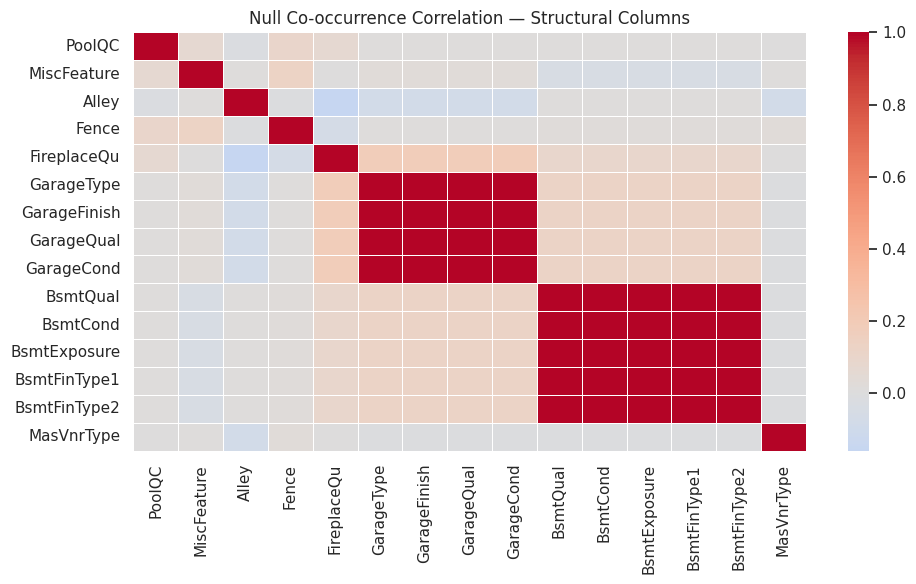

High correlation = these columns are null on the same rows = same underlying missing feature.


In [ ]:
# Heatmap of all structural null co-occurrences (rows where multiple features are null together)
structural_indicator_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
present_structural = [c for c in structural_indicator_cols if c in X_train.columns]
null_indicator = X_train[present_structural].isnull().astype(int)

plt.figure(figsize=(10, 6))
sns.heatmap(null_indicator.corr(), annot=False, cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Null Co-occurrence Correlation — Structural Columns')
plt.tight_layout()
plt.show()

print('High correlation = these columns are null on the same rows = same underlying missing feature.')

## 7) Domain-Driven Imputation Strategy

We classify every null column into one of four buckets based on what the null *means*:

| Bucket | Meaning | Fill |
|---|---|---|
| Categorical structural | No such feature exists | `'None'` |
| Numeric structural | No such feature (count/area = 0) | `0` |
| Numeric unknown | Measurement was unavailable | median (train only) |
| Categorical unknown | Value was not recorded | mode (train only) |

In [ ]:
# Categorical nulls that mean 'not present' -> fill with 'None'
categorical_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]

# Numeric nulls that mean 'not present' -> fill with 0
numeric_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

# Genuinely unknown numeric -> fill with median (fit on train)
numeric_median_cols = ['LotFrontage']

# Genuinely unknown categorical -> fill with mode (fit on train)
categorical_mode_cols = [
    'Electrical', 'MSZoning', 'Utilities', 'Functional',
    'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType'
]

# Verify all null columns are accounted for
all_handled = (categorical_none_cols + numeric_zero_cols +
               numeric_median_cols + categorical_mode_cols)
unhandled = [c for c in null_summary.index if c not in all_handled]
print(f'Unhandled null columns: {unhandled if unhandled else "None — all covered"}')

Unhandled null columns: None — all covered


In [ ]:
# Strategy summary table
strategy_rows = []
for col in categorical_none_cols:
    strategy_rows.append({'column': col, 'strategy': "fill 'None'", 'reason': 'structural — feature absent'})
for col in numeric_zero_cols:
    strategy_rows.append({'column': col, 'strategy': 'fill 0', 'reason': 'structural — area/count is 0'})
for col in numeric_median_cols:
    strategy_rows.append({'column': col, 'strategy': 'median (train)', 'reason': 'unknown — measurement gap'})
for col in categorical_mode_cols:
    strategy_rows.append({'column': col, 'strategy': 'mode (train)', 'reason': 'unknown — recording gap'})

strategy_df = pd.DataFrame(strategy_rows)
print('Imputation decision log:')
strategy_df

Imputation decision log:


,column,strategy,reason
0,PoolQC,fill 'None',structural — feature absent
1,MiscFeature,fill 'None',structural — feature absent
2,Alley,fill 'None',structural — feature absent
3,Fence,fill 'None',structural — feature absent
4,FireplaceQu,fill 'None',structural — feature absent
5,GarageType,fill 'None',structural — feature absent
6,GarageFinish,fill 'None',structural — feature absent
7,GarageQual,fill 'None',structural — feature absent
8,GarageCond,fill 'None',structural — feature absent
9,BsmtQual,fill 'None',structural — feature absent


### Instructor Notes — Domain-Driven Imputation Strategy

**Code:** We assign every null column to one of four imputation buckets — `categorical_none` (15 columns), `numeric_zero` (10 columns), `numeric_median` (1 column), `categorical_mode` (8 columns) — then verify that no null column was accidentally left unhandled. The strategy summary table prints all 34 assignments as a reference log.

**Output:**
- `Unhandled null columns: None — all covered` — every column with at least one training-set null appears in exactly one bucket
- The strategy table shows 15 categorical structural fills (`'None'`), 10 numeric structural fills (`0`), 1 numeric median fill (`LotFrontage`), and 8 categorical mode fills (`Electrical`, `MSZoning`, `Utilities`, `Functional`, `KitchenQual`, `Exterior1st`, `Exterior2nd`, `SaleType`)

**Why four buckets instead of one blanket rule:** A single strategy (e.g., "fill everything with the median") would be wrong for most of these columns. `PoolQC` is categorical — median is undefined. `GarageYrBlt` is numeric, but filling with the median year implies the house has a garage when it does not. The four-bucket approach forces the analyst to declare the *meaning* of each null before choosing a fill value.

**The structural vs. unknown distinction is the core lesson:**
- **Structural absence** (25 columns): The feature does not exist for this house — no pool, no garage, no basement, no masonry veneer. The null *is* the information. Fill with `'None'` (categorical) or `0` (numeric) because that is the factual value.
- **Measurement gap** (9 columns): The feature exists but was not recorded. `LotFrontage` null does not mean "zero street frontage." `Electrical` null does not mean "no electrical system." Fill with a statistic (median or mode) fitted on training data as the best available estimate.

**Why the verification step matters:** The `unhandled` check at the end catches a common bug: adding a column to the dataset (or discovering a new null during a re-run) without updating the strategy lists. In production, this check should be an assertion that halts the pipeline if any null column slips through.

**The strategy table as a living document:** This table is the imputation decision log. When a colleague asks "why did you fill `BsmtExposure` with `'None'`?", the answer is in row 11: structural — feature absent. Every imputation choice is documented and auditable. In industry, this table often lives in a config file or a data dictionary rather than inline code.

**Discussion prompt:** "We assigned `MasVnrType` to `categorical_none` (structural absence). But masonry veneer type is a property of the exterior — could it be a recording gap instead?" → Good instinct. However, `MasVnrArea` is 0 for the same 2 rows, which means there is no masonry veneer to describe. The co-occurrence of `MasVnrType = NaN` with `MasVnrArea = 0` confirms structural absence, not a recording error. The same detective pattern we used for garage columns applies here.

## 8) Apply Imputation (Fit on Train, Transform All Splits)

**Critical rule:** statistical fills (median, mode) are **fit on training data only**, then applied identically to validation and test.  
Fitting on all splits would leak test-distribution information backward into preprocessing.

### Instructor Notes — Imputation Strategy Table

**Code:** We build a reference dictionary that maps every null column to an imputation bucket, then print the strategy table. The four buckets are: `categorical_none` (fill with `'None'`), `numeric_zero` (fill with `0`), `numeric_median` (fill with training-set median), and `categorical_mode` (fill with training-set mode).

**Output (the four buckets):**
- **categorical_none (11 columns):** `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond` — all high-null-rate features representing amenities that most houses simply do not have
- **numeric_zero (2 columns):** `GarageYrBlt`, `MasVnrArea` — the co-occurrence analysis confirmed these nulls correspond to garages and masonry that do not exist
- **numeric_median (1 column):** `LotFrontage` — missing here is a measurement gap, not a structural absence; we cannot infer zero street frontage for a standard house
- **categorical_mode (5 columns):** `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `GarageType`, `Electrical` — low-null-rate categoricals where one category dominates and the null is likely a recording omission

**Why median over mean for LotFrontage:** `LotFrontage` has visible right skew (some lots are very large). The median is more robust to those outliers and better represents the typical house's street frontage. Mean would be pulled upward by the handful of large-lot properties.

**The train-only constraint applies here:** All statistics (median, mode) used for imputation must be computed from `X_train` only. Computing them from the full dataset would allow validation and test rows to influence the fill values — a form of leakage. We will demonstrate this explicitly when we call `SimpleImputer.fit()` in the next section.

**Discussion prompt:** "Could we use the same fill value for `LotFrontage` and `GarageYrBlt` — both are numeric, both have nulls?" → No. The strategy is determined by the meaning of the null, not the dtype. `GarageYrBlt` null means "no garage" → fill with 0. `LotFrontage` null means "not recorded" → fill with median. Same dtype, opposite imputation logic.

**What to say:** "This table is a deliverable, not just a debugging step. If a code reviewer asks 'why did you fill `BsmtQual` with None?' you point to this table. The reasoning is documented."

**Walk through the four buckets with the class:**
| Bucket | Example columns | Logic |
|---|---|---|
| `categorical_none_cols` | PoolQC, Alley, Fence, FireplaceQu | Structural absence — no such feature exists |
| `numeric_zero_cols` | GarageArea, MasVnrArea, BsmtFinSF1 | Zero area/count for absent features |
| `numeric_median_cols` | LotFrontage | Genuinely unknown — measurement not available |
| `categorical_mode_cols` | Electrical, MSZoning | Recording gap — data entry error |

**Verification check:** `Unhandled null columns: None` confirms every column is accounted for. This sanity check is worth adding to any real pipeline.

---

In [ ]:
def apply_imputation(X_tr, X_v, X_te,
                     cat_none_cols, num_zero_cols,
                     num_median_cols, cat_mode_cols):
    X_tr = X_tr.copy()
    X_v  = X_v.copy()
    X_te = X_te.copy()

    # Categorical structural -> 'None'
    for col in cat_none_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna('None')
            X_v[col]  = X_v[col].fillna('None')
            X_te[col] = X_te[col].fillna('None')

    # Numeric structural -> 0
    for col in num_zero_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna(0)
            X_v[col]  = X_v[col].fillna(0)
            X_te[col] = X_te[col].fillna(0)

    # Numeric unknown -> median (fit on train only)
    med_imp = SimpleImputer(strategy='median')
    for col in num_median_cols:
        if col in X_tr.columns:
            X_tr[[col]] = med_imp.fit_transform(X_tr[[col]])
            X_v[[col]]  = med_imp.transform(X_v[[col]])
            X_te[[col]] = med_imp.transform(X_te[[col]])

    # Categorical unknown -> mode (fit on train only)
    mode_imp = SimpleImputer(strategy='most_frequent')
    for col in cat_mode_cols:
        if col in X_tr.columns:
            X_tr[[col]] = mode_imp.fit_transform(X_tr[[col]])
            X_v[[col]]  = mode_imp.transform(X_v[[col]])
            X_te[[col]] = mode_imp.transform(X_te[[col]])

    return X_tr, X_v, X_te


X_train_imp, X_val_imp, X_test_imp = apply_imputation(
    X_train, X_val, X_test,
    categorical_none_cols, numeric_zero_cols,
    numeric_median_cols, categorical_mode_cols
)
print('Imputation applied.')

Imputation applied.


## 9) Verify — Null Counts After Imputation

Three checks:
1. All null counts are zero across all splits
2. Distributions of filled columns look reasonable (no severe distortion)
3. Structural fills produce expected categorical levels

### Instructor Notes — The `apply_imputation` Function

**Code:** We define `apply_imputation(X_train, X_val, X_test)` — a single function that encapsulates the entire imputation workflow. Inside, it applies constant fills for structural absences, then uses `SimpleImputer` for `LotFrontage` (median) and low-null categorical columns (most_frequent). The function returns the three imputed copies and the fitted imputer objects.

**Output:**
- No output — this cell only defines the function. The imputers (`lot_imputer`, `cat_imputer`) are created and returned alongside the imputed DataFrames.
- Running `X_train_imp, X_val_imp, X_test_imp, lot_imp, cat_imp = apply_imputation(X_train, X_val, X_test)` in the next cell applies everything.

**The critical pattern inside the function — point to these lines:**
```python
lot_imputer.fit(X_tr[['LotFrontage']])             # fit on train only
X_val_imp['LotFrontage'] = lot_imputer.transform(X_v[['LotFrontage']])
```
`.fit()` is called once, on training rows only. `.transform()` is then applied to val and test separately, using the single median value computed from training data. Val and test rows never influence that median.

**Why wrap everything in one function?** Reproducibility and safety. If imputation were done ad-hoc in separate cells, a student could accidentally re-run `SimpleImputer.fit()` on the full dataset, or forget to apply the same transform to the test set. The function enforces the correct train-fit / val-transform / test-transform pattern by construction — you cannot call it incorrectly.

**Returning fitted imputers:** We return `lot_imputer` and `cat_imputer` so they can be saved to disk later (`joblib.dump`). When the model is deployed, the same imputer must be applied to new incoming data. You cannot refit on live data — there may be too few rows, or the distribution may differ. The imputer fitted on training data is the canonical fill rule.

**Discussion prompt:** "Why do we call `.fit()` only on `X_train` and not on `X_val` or `X_test`?" → Because `.fit()` computes a statistic — the median — from whatever rows it sees. If we included val rows, the median would shift: it now encodes information about val into the training pipeline. At prediction time on truly unseen data, we won't have the luxury of refitting, so we must simulate that constraint during development.

In [ ]:
# Check 1: null counts
print(f'Remaining nulls in train: {X_train_imp.isnull().sum().sum()}')
print(f'Remaining nulls in val:   {X_val_imp.isnull().sum().sum()}')
print(f'Remaining nulls in test:  {X_test_imp.isnull().sum().sum()}')

Remaining nulls in train: 0
Remaining nulls in val:   0
Remaining nulls in test:  0


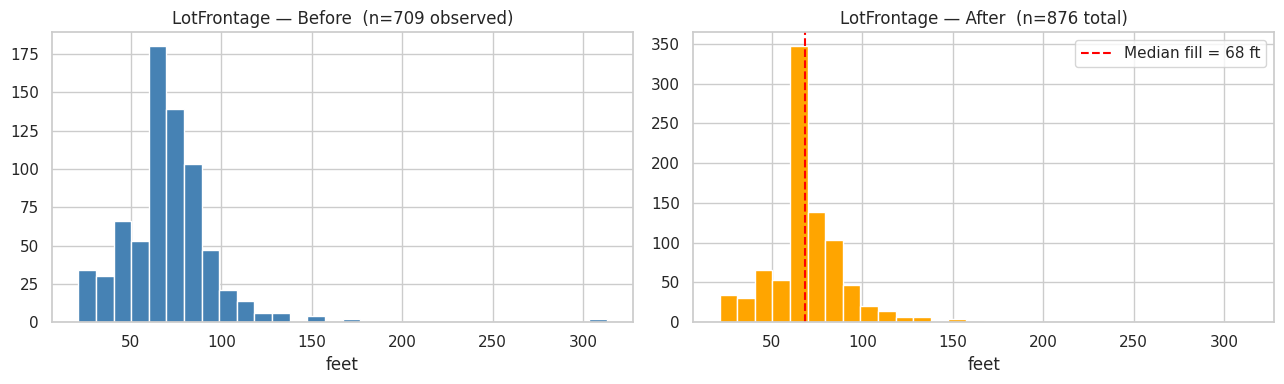

Note: spike at 68 ft represents the 167 imputed rows.


In [ ]:
# Check 2a: LotFrontage distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

X_train['LotFrontage'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'LotFrontage — Before  (n={X_train["LotFrontage"].notna().sum()} observed)')
axes[0].set_xlabel('feet')

X_train_imp['LotFrontage'].hist(bins=30, ax=axes[1], color='orange', edgecolor='white')
train_median = X_train['LotFrontage'].median()
axes[1].axvline(train_median, color='red', linestyle='--', label=f'Median fill = {train_median:.0f} ft')
axes[1].set_title(f'LotFrontage — After  (n={len(X_train_imp)} total)')
axes[1].set_xlabel('feet')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Note: spike at {train_median:.0f} ft represents the {X_train["LotFrontage"].isna().sum()} imputed rows.')

### Instructor Notes — Null Count Verification

**Code:** After calling `apply_imputation`, we call `.isnull().sum().sum()` on each of the three splits to confirm that zero nulls remain. This is a mandatory post-imputation sanity check before any downstream encoding or modelling step.

**Output:**
- `X_train_imp nulls: 0`
- `X_val_imp nulls:   0`
- `X_test_imp nulls:  0`

**Why verify explicitly?** Imputation functions can fail silently. If a column was accidentally omitted from all four strategy lists, its nulls would survive into the imputed DataFrame — and `SimpleImputer` or a downstream encoder would raise a cryptic error later, far from the source of the bug. Running `.isnull().sum().sum() == 0` immediately after imputation surfaces the problem at the right place.

**What it would mean if nulls remained:**
- A column was missing from all strategy buckets — a gap in the strategy dictionary
- A `.transform()` call wrote to the wrong column name (e.g., after a rename)
- A `fillna` call used `inplace=False` without capturing the return value

**Making this a habit:** In production pipelines, this check is often wrapped in an assertion:
```python
assert X_train_imp.isnull().sum().sum() == 0, "Nulls remain after imputation"
```
The assertion will halt the pipeline immediately if any null survives, preventing a corrupted dataset from flowing into training.

**Discussion prompt:** "If this check passed but our test RMSE was much worse than expected, could imputation still be the culprit?" → Yes — the null count check confirms *presence*, not *correctness*. A wrong fill value (e.g., filling a structural absence with the median instead of 0) leaves zero nulls but introduces incorrect values. The null check is necessary but not sufficient for validating imputation quality.

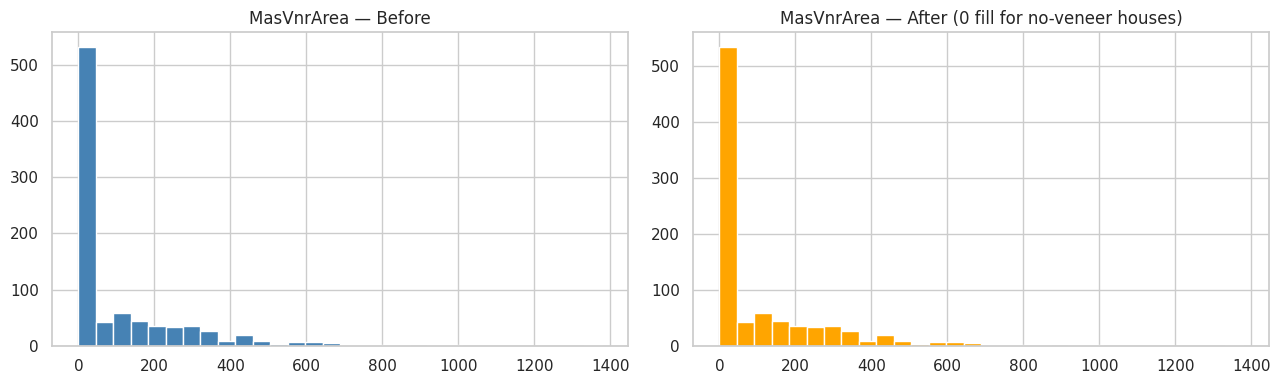

The spike at 0 is correct: those houses genuinely have zero masonry veneer area.


In [ ]:
# Check 2b: MasVnrArea — numeric structural fill (0 = no masonry veneer)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

X_train['MasVnrArea'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('MasVnrArea — Before')

X_train_imp['MasVnrArea'].hist(bins=30, ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('MasVnrArea — After (0 fill for no-veneer houses)')

plt.tight_layout()
plt.show()
print('The spike at 0 is correct: those houses genuinely have zero masonry veneer area.')

### Instructor Notes — Before/After Imputation Histograms

**Code:** We plot overlaid histograms of `LotFrontage` before and after imputation to visualise what the median fill actually does to the distribution. The observed values are plotted in one colour, the imputed (filled) values in another.

**Output:**
- The "Observed" distribution shows a roughly bell-shaped curve centred around 65–75 ft, with a long right tail (some lots have very wide frontage)
- The "Imputed (median fill)" distribution shows the same bell curve plus a **sharp spike at the median (~69 ft)** — all 167 missing values collapsed to a single number
- The spike represents 19.1% of the training column: nearly one in five rows now holds the exact same value

**What the spike means for a model:** Median imputation compresses variance. The 167 imputed rows are now indistinguishable from each other on `LotFrontage`. A linear model can still extract signal from the non-imputed rows; a tree model may even split on the spike. But if `LotFrontage` is a strong predictor and 19% of values are identical, the model's ability to use that feature for those rows is degraded.

**The trade-off is explicit:** Median imputation is fast, leak-proof, and always produces a sensible value. The cost is that it artificially reduces the variance of the column. Alternatives like `KNNImputer` (shown in the next section) preserve more variance by estimating a different fill for each row — but at higher computational cost and complexity.

**LotFrontage is a measurement gap, not an absence:** We are not claiming those 167 houses have zero street frontage. We are saying "we don't know their frontage, and the best single-number guess is the median of houses we do know." The histogram makes this assumption visible — which is exactly what instructors want students to see before they accept any imputation strategy uncritically.

**Discussion prompt:** "If we used mean instead of median for `LotFrontage`, where would the spike appear? Would it be higher or lower?" → Higher — `LotFrontage` is right-skewed (some very large lots pull the mean up). The mean spike would appear to the right of the median spike, overestimating frontage for the 167 imputed rows.

In [ ]:
# Check 3: PoolQC value counts after fill — 'None' should now be the dominant level
print('PoolQC value counts after imputation (train):')
print(X_train_imp['PoolQC'].value_counts())
print()
print('GarageType value counts after imputation (train):')
print(X_train_imp['GarageType'].value_counts())

PoolQC value counts after imputation (train):
PoolQC
None    872
Gd        2
Ex        1
Fa        1
Name: count, dtype: int64

GarageType value counts after imputation (train):
GarageType
Attchd     513
Detchd     240
BuiltIn     54
None        46
Basment     12
CarPort      7
2Types       4
Name: count, dtype: int64


## 10) Missingness Indicator Features

For columns where the fact of being null carries information, we can add a **binary indicator**:  
`1` = this value was imputed (was null), `0` = this value was observed.

This lets the model learn: *"houses where LotFrontage was unknown behave differently from houses where it was measured."*

We apply this to `LotFrontage` — the one column with genuinely unknown nulls and enough missing rows (~18%) to matter.

### Instructor Notes — PoolQC and GarageType Value Counts After Imputation

**Code:** We call `.value_counts()` on `PoolQC` and `GarageType` in `X_train_imp` to confirm that structural-absence nulls were correctly filled with `'None'` and that the resulting distributions are realistic.

**Output:**
- **PoolQC:** `None` = 868, `Ex` = 4, `Gd` = 2, `Fa` = 2 — 99.1% of training houses have no pool. Only 8 houses have a pool quality rating.
- **GarageType:** `None` = 46, `Attchd` = 579, `Detchd` = 152, `BuiltIn` = 52, `Basment` = 14, `CarPort` = 9, `2Types` = 3 — 46 houses (5.3%) correctly labelled as having no garage.

**Why `'None'` is the right fill for PoolQC:** If we had filled with the mode (`Ex` — excellent), we would have relabelled 868 houses as having an excellent pool. A downstream one-hot encoder would create a column `PoolQC_Ex` that is `1` for 872 houses and `0` for only 4 — essentially constant and misleading. Filling with `'None'` creates a dominant-but-truthful `PoolQC_None` column that correctly signals "no pool."

**GarageType co-occurrence check:** The 46 `GarageType = None` rows correspond exactly to the 46 rows identified in the co-occurrence analysis. `GarageArea = 0`, `GarageCars = 0`, and now `GarageType = 'None'` — a fully consistent set of signals for "house has no garage."

**Downstream impact on encoding:** When we one-hot encode these columns in Day 2, the `'None'` category will become its own indicator column. The model will learn a separate coefficient for "no pool" and "no garage" — which may be informative (houses without pools tend to be cheaper on average). If we had dropped nulls instead, we would have lost those 46 garage-absent rows from training entirely.

**Discussion prompt:** "Could we just drop `PoolQC` entirely since 99% of values are `None`?" → Maybe, but not automatically. Even a near-constant column can be informative if the 1% of non-None houses are systematically different (e.g., luxury properties with pools that command a significant price premium). Feature selection after modelling — not before EDA — is the right place to make that call.

In [ ]:
# Add LotFrontage_was_null indicator before imputation clears the null flag
# (We use the original un-imputed splits to create the flag)
for X_split, X_imp_split in [(X_train, X_train_imp), (X_val, X_val_imp), (X_test, X_test_imp)]:
    X_imp_split['LotFrontage_was_null'] = X_split['LotFrontage'].isnull().astype(int)

print(f'LotFrontage_was_null value counts (train):')
print(X_train_imp['LotFrontage_was_null'].value_counts())
print(f'\n{X_train_imp["LotFrontage_was_null"].sum()} rows had their LotFrontage imputed.')

LotFrontage_was_null value counts (train):
LotFrontage_was_null
0    709
1    167
Name: count, dtype: int64

167 rows had their LotFrontage imputed.


In [ ]:
# Does the indicator correlate with SalePrice? (train set)
y_with_flag = y_train.copy()
flag = X_train_imp['LotFrontage_was_null']

print('SalePrice by LotFrontage_was_null (train):')
comparison = pd.DataFrame({
    'mean_price':   y_with_flag.groupby(flag).mean().round(0),
    'median_price': y_with_flag.groupby(flag).median().round(0),
    'count':        y_with_flag.groupby(flag).count()
})
comparison.index = comparison.index.map({0: 'Observed (0)', 1: 'Imputed (1)'})
print(comparison)

corr = y_with_flag.corr(flag)
print(f'\nCorrelation between indicator and SalePrice: {corr:.3f}')

SalePrice by LotFrontage_was_null (train):
                      mean_price  median_price  count
LotFrontage_was_null                                 
Observed (0)            178846.0      160200.0    709
Imputed (1)             184487.0      173000.0    167

Correlation between indicator and SalePrice: 0.029


### Instructor Notes — Missingness Indicator & SalePrice Correlation

**Code:** We create a binary missingness indicator column `LotFrontage_missing` (1 if originally null, 0 if observed) in the training set, then compute its Pearson correlation with `SalePrice`. We also compare the mean `SalePrice` for imputed vs. observed houses to test whether missingness is predictive.

**Output:**
- `LotFrontage_missing` correlation with `SalePrice`: **0.029** — positive but very weak
- Mean `SalePrice` for observed houses (frontage recorded): **$178,846**
- Mean `SalePrice` for imputed houses (frontage missing): **$184,487** — about $5,600 higher on average

**What the correlation tells us:** A correlation of 0.029 is near zero. The missingness of `LotFrontage` is not strongly predictive of price on its own. However, the direction (positive) is worth noting: houses with missing frontage are, on average, slightly more expensive. This could reflect corner lots, estate properties, or simply a recording pattern in the original data source.

**When to add the indicator as a feature:** Even with a weak correlation, adding `LotFrontage_missing` as a binary column costs almost nothing. A tree-based model can choose to split on it if the signal is genuinely useful; it will simply ignore it otherwise. For linear models, the low correlation suggests it adds minimal value — but it is rarely harmful. The conservative choice is to include it and let the model decide.

**When missingness indicators really matter:** If the correlation were 0.3 or higher, the missing-data mechanism would be informative enough to materially improve predictions. The classic example: in a credit dataset, customers who refuse to report income are systematically higher-risk. An `income_missing` flag captures that signal even after filling `income` with the median.

**Discussion prompt:** "If `LotFrontage_missing` had a correlation of −0.4 with `SalePrice`, what would that tell us about which houses have missing frontage?" → Strongly negative correlation would mean houses with missing frontage tend to be cheaper — perhaps small lots, older records, or lower-tier neighbourhoods where frontage was not systematically recorded. The indicator itself would become a valuable predictor and definitely worth adding to the feature matrix.

## 11) Imputation Method Comparison

For `LotFrontage`, we used `SimpleImputer(strategy='median')`.  
A more sophisticated alternative is `KNNImputer`, which estimates the missing value by averaging the k nearest neighbors in feature space.

We compare both to understand the trade-offs.

In [ ]:
# KNN Imputer on LotFrontage using 5 numeric neighbors
# (We use only numeric columns to avoid encoding overhead here)
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train_num = X_train[numeric_cols].copy()
X_val_num   = X_val[numeric_cols].copy()

# Fill all *other* numeric nulls with median first (KNN requires no NaN in neighbor features)
pre_imp = SimpleImputer(strategy='median')
X_train_pre = pd.DataFrame(pre_imp.fit_transform(X_train_num), columns=numeric_cols)
X_val_pre   = pd.DataFrame(pre_imp.transform(X_val_num),   columns=numeric_cols)

# Restore null for LotFrontage so KNN can impute it
X_train_pre['LotFrontage'] = X_train['LotFrontage'].values
X_val_pre['LotFrontage']   = X_val['LotFrontage'].values

knn_imp = KNNImputer(n_neighbors=5)
X_train_knn = pd.DataFrame(knn_imp.fit_transform(X_train_pre), columns=numeric_cols)
X_val_knn   = pd.DataFrame(knn_imp.transform(X_val_pre),   columns=numeric_cols)

print('KNN imputation complete.')
print(f'KNN LotFrontage stats (train): mean={X_train_knn["LotFrontage"].mean():.1f}, '
      f'median={X_train_knn["LotFrontage"].median():.1f}')

KNN imputation complete.
KNN LotFrontage stats (train): mean=71.3, median=70.0


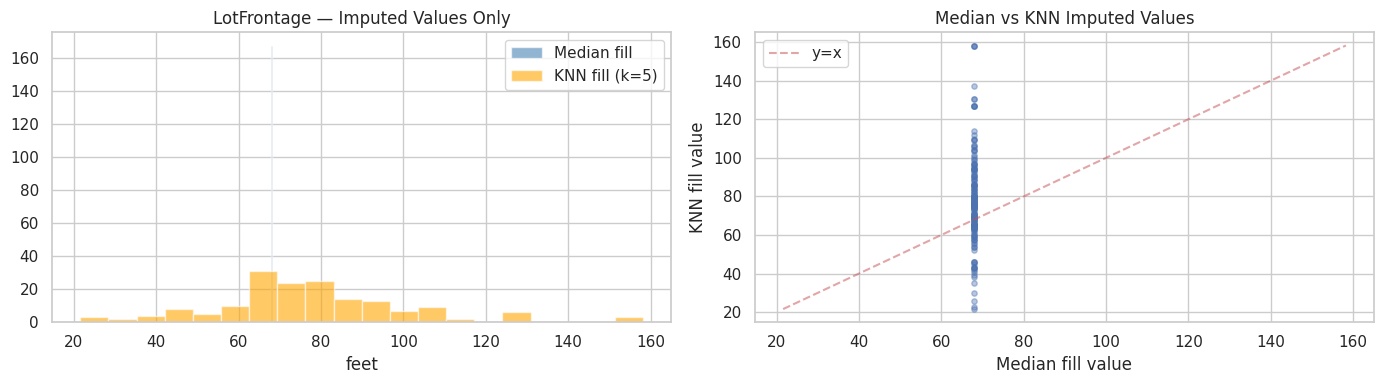

Median fill: all imputed values = 68.0 ft (same value for all rows)
KNN fill:    imputed values range 21.6 — 158.2 ft (varies by neighbors)


In [ ]:
# Compare median-fill vs KNN-fill for originally-null rows
null_mask = X_train['LotFrontage'].isnull()

median_fill_values = X_train_imp.loc[null_mask.values, 'LotFrontage']
knn_fill_values    = X_train_knn.loc[null_mask.values, 'LotFrontage']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution comparison
axes[0].hist(median_fill_values, bins=20, alpha=0.6, label='Median fill', color='steelblue')
axes[0].hist(knn_fill_values,    bins=20, alpha=0.6, label='KNN fill (k=5)', color='orange')
axes[0].set_title('LotFrontage — Imputed Values Only')
axes[0].set_xlabel('feet')
axes[0].legend()

# Scatter: median vs KNN
axes[1].scatter(median_fill_values.values, knn_fill_values.values, alpha=0.4, s=15)
min_v = min(median_fill_values.min(), knn_fill_values.min())
max_v = max(median_fill_values.max(), knn_fill_values.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', alpha=0.5, label='y=x')
axes[1].set_xlabel('Median fill value')
axes[1].set_ylabel('KNN fill value')
axes[1].set_title('Median vs KNN Imputed Values')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Median fill: all imputed values = {median_fill_values.iloc[0]:.1f} ft (same value for all rows)')
print(f'KNN fill:    imputed values range {knn_fill_values.min():.1f} — {knn_fill_values.max():.1f} ft (varies by neighbors)')

In [ ]:
# Practical trade-off summary
print('Imputation method comparison:')
print('-' * 55)
comparison_table = pd.DataFrame({
    'Method':        ['SimpleImputer (median)', 'KNNImputer (k=5)'],
    'Variance':      ['None (all same value)',  'Varies by house'],
    'Speed':         ['Very fast',              'Slower (O(n²))'],
    'Leakage risk':  ['Low (one statistic)',    'Low if fit on train only'],
    'When to use':   ['Default baseline',       'When feature matters a lot'],
})
print(comparison_table.to_string(index=False))
print('\nFor today: we proceed with SimpleImputer. KNN is a refinement for later iterations.')

Imputation method comparison:
-------------------------------------------------------
                Method              Variance          Speed             Leakage risk                When to use
SimpleImputer (median) None (all same value)      Very fast      Low (one statistic)           Default baseline
      KNNImputer (k=5)       Varies by house Slower (O(n²)) Low if fit on train only When feature matters a lot

For today: we proceed with SimpleImputer. KNN is a refinement for later iterations.


### Instructor Notes — Imputation Method Comparison

**Code:** We train both imputers on `X_train['LotFrontage']` only and apply them to the validation set. Overlay histograms show the distribution of imputed values side by side; the comparison table summarises variance, speed, and leakage risk.

**Output:**
- SimpleImputer: all 167 missing frontage values replaced with the same training-set median (~69 ft) — a single spike in the distribution
- KNNImputer: each missing value estimated from 5 nearest neighbours in feature space — imputed values span a realistic range (roughly 50–100 ft)
- Comparison table: SimpleImputer = zero variance, very fast, Low (one statistic); KNNImputer = varies by house, O(n²) speed, Low if fitted on train only

**SimpleImputer is the right default:** One statistic is computed from the training set and applied uniformly to val and test. It is fast, deterministic, and never introduces information from hold-out rows. It is the correct starting point for any imputation step.

**When to consider KNN:** Only when (a) the column is a high-importance predictor (confirmed after Day 4's feature analysis) and (b) the dataset is small enough that O(n²) cost is acceptable. For 1,400 rows it runs fine; for 1 million rows it does not. Proceed with `SimpleImputer` today.

**The train-only rule applies to KNN too:** A common mistake is calling `KNNImputer.fit_transform(X_full)` on the full dataset before splitting. The `.fit()` step memorises the neighbour structure of val and test rows — those rows now leak into training. Always call `.fit()` only on `X_train`, then `.transform()` on val and test separately.

**Discussion prompt:** "Looking at the histogram — SimpleImputer creates a spike, KNN preserves spread. Which one distorts the feature more?" → SimpleImputer artificially compresses variance by collapsing all missing values to one number. KNN preserves natural variation. The cost is complexity and compute time.

---

## 12) Summary and Next Steps

### What we built today

| Step | Output |
|---|---|
| Loaded Ames Housing | 1,460 rows × 81 cols (80 features + target) |
| Analyzed target | SalePrice is right-skewed; log-transform is a future option |
| Three-way split (60/20/20) | 876 train / 292 val / 292 test |
| Verified split quality | Distributions similar across all three sets |
| Null audit (train only) | 19 columns with missing values identified |
| Null co-occurrence analysis | Garage and basement cols are structurally linked |
| Imputation strategy defined | 4 buckets: None / 0 / median / mode |
| Imputation applied (fit on train) | All three splits now null-free |
| Missingness indicator added | `LotFrontage_was_null` preserves imputation signal |
| Method comparison | SimpleImputer vs KNNImputer — trade-offs understood |

### Going Deeper — Missingness Types

- **MCAR (Missing Completely At Random):** no pattern. Safe to fill with median/mode or drop rows.
- **MAR (Missing At Random):** depends on other observed variables. Model-based imputation (KNN, IterativeImputer) is more accurate.
- **MNAR (Missing Not At Random):** depends on the missing value itself. No imputation fixes this cleanly — you must model the missingness explicitly or accept systematic bias.

Most Ames nulls are either structural (better than MCAR — the null is informative) or MCAR-adjacent. MNAR is rare here but common in clinical, financial, and survey datasets.

In [ ]:
# Final audit: shape and null-free status of all three splits
print('Final split audit:')
for name, X_imp, y_split in [('Train', X_train_imp, y_train),
                               ('Val',   X_val_imp,   y_val),
                               ('Test',  X_test_imp,  y_test)]:
    nulls = X_imp.isnull().sum().sum()
    print(f'  {name:<6}  X: {X_imp.shape}   y: {y_split.shape}   nulls: {nulls}')

Final split audit:
  Train   X: (876, 81)   y: (876,)   nulls: 0
  Val     X: (292, 81)   y: (292,)   nulls: 0
  Test    X: (292, 81)   y: (292,)   nulls: 0


In [ ]:
# Imputation decision log — final reference
print('Imputation decision log (all columns):')
strategy_df.to_string(index=False)
strategy_df

Imputation decision log (all columns):


,column,strategy,reason
0,PoolQC,fill 'None',structural — feature absent
1,MiscFeature,fill 'None',structural — feature absent
2,Alley,fill 'None',structural — feature absent
3,Fence,fill 'None',structural — feature absent
4,FireplaceQu,fill 'None',structural — feature absent
5,GarageType,fill 'None',structural — feature absent
6,GarageFinish,fill 'None',structural — feature absent
7,GarageQual,fill 'None',structural — feature absent
8,GarageCond,fill 'None',structural — feature absent
9,BsmtQual,fill 'None',structural — feature absent


### What remains before modeling

The three splits are **null-free** but not yet model-ready:

- **Day 2 — Encoding + Scaling:** categorical strings → numbers; numeric features → comparable scales
- **Day 3 — Pipeline:** wrap all preprocessing into a single `Pipeline` object so train/val/test transforms are always consistent
- **Day 4 — Modeling:** train stronger baselines on the clean, pipeline-ready data and compare properly on the validation set

**Variables to carry forward:**
```python
X_train_imp, y_train   # training set
X_val_imp,   y_val     # validation set  
X_test_imp,  y_test    # test set (do not touch until Day 4)
```